# Manual Implementation of Decision Trees

[Use numpy for all questions (`sklearn` is only allowed to *check* your results)]

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

## Classification tree from scratch

**We will grow a binary decision tree, node by node, and use it to classify points in the plane.**

*A tree is nothing but a sequence of yes/no questions of the form "is $x_j \leq t$ ?". Fitting one means
choosing, at every node, the column $j$ and the threshold $t$ that make the two children as **pure** as
possible, then recursing on each child. There is no gradient and no global loss here, only that greedy rule
repeated, which is also why a tree needs no scaling, no dummy encoding and no distributional assumption.*

Two plotting functions are provided:

In [2]:
def plot_data(X, y):
    plt.plot(X[y == 1, 0], X[y == 1, 1], 'o', color='crimson', ms=4, label='class 1')
    plt.plot(X[y == 0, 0], X[y == 0, 1], 's', color='royalblue', ms=4, label='class 0')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')

In [3]:
def plot_regions(predict, X, y, res=200, pad=0.5, title=None):
    g1 = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, res)
    g2 = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, res)
    G1, G2 = np.meshgrid(g1, g2)
    Z = np.asarray(predict(np.c_[G1.ravel(), G2.ravel()])).reshape(G1.shape)
    plt.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5],
                 colors=['royalblue', 'crimson'], alpha=0.15)
    plot_data(X, y)
    if title:
        plt.title(title)

Build a dataset that a single question cannot solve, two interleaved moons.
Write a function `moons(n_per, noise=0.3)` returning `X` $(2 n_{per} \times 2)$ and `y`:

- class $1$ is the upper half of the unit circle, $(\cos t, \sin t)$ for $t$ uniform in $[0, \pi]$,
- class $0$ is $(1 - \cos t,\; 0.5 - \sin t)$ for $t$ uniform in $[0, \pi]$,
- both get gaussian noise of standard deviation `noise` on each coordinate.

Labels are $y_i \in \{0, 1\}$ (integers, they will be used as counts and indices).

Generate a **training set** of $300$ points ($150$ per class) and a **test set** of $1000$ points
($500$ per class). The data is synthetic, so we can afford a large test set, and the curves later on will be
much less noisy for it.

In [4]:
def moons(n, noise=0.3):
    t = np.linspace(0, np.pi, n)
    x1 = np.stack([np.cos(t), np.sin(t)]) + noise*np.random.randn(2*n).reshape( (2,n) )
    x0 = np.stack([1-np.cos(t), 0.5-np.sin(t)]) + noise*np.random.randn(2*n).reshape( (2,n) )
    X = np.concat([x1, x0], axis=1)
    y = np.concat([np.ones(n), np.zeros(n)])
    return X.T, y

moons(3)

(array([[ 1.14901425,  0.45690896],
        [-0.04147929,  0.92975399],
        [-0.80569344, -0.07024109],
        [ 0.47376384,  0.66276801],
        [ 1.23023042, -0.63902531],
        [ 1.85915768,  0.36028107]]),
 array([1., 1., 1., 0., 0., 0.]))

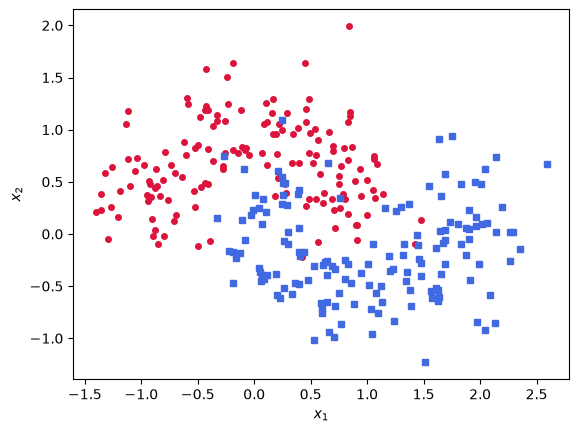

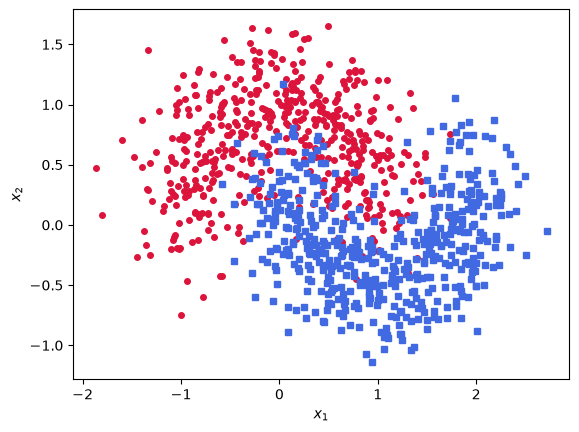

In [5]:
X_train, y_train = moons(150)
X_test, y_test = moons(500)

plot_data(X_train, y_train)
plt.show()
plot_data(X_test, y_test)

### Measuring impurity

A node is **pure** when all its rows carry the same label. The Gini impurity measures how far from pure it
is:

$$ G(y) = 1 - \sum_{k} p_k^2 \qquad \text{where } p_k \text{ is the proportion of class } k \text{ in the node} $$

Here `y` is **the labels of the rows sitting in one node**: the whole training set at the root, and the
labels of one side of a split further down the tree. The features never come into it, impurity looks at the
labels alone, so `gini` takes one array of labels, of any length, and returns one number.

Write `gini(y)` and check it on a pure node, a $50/50$ node and a $90/10$ node:

```python
gini(np.array([1, 1, 1, 1]))     # -> 0.0    a pure node
gini(np.array([0, 1, 0, 1]))     # -> 0.5    as impure as a two-class node gets
gini(np.array([0] * 9 + [1]))    # -> 0.18   nearly pure
```

*`np.unique(y, return_counts=True)` gives you the classes present and their counts in one call.*

In [6]:
def gini(y):
    _classes, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    return 1 - np.sum(proportions**2)


gini(np.array([1, 1, 1, 1])),\
gini(np.array([0, 1, 0, 1])),\
gini(np.array([0] * 9 + [1]))    # -> 0.0, 0.5, 0.18   nearly pure

(np.float64(0.0), np.float64(0.5), np.float64(0.17999999999999994))

Two other measures could do the same job, the entropy and the misclassification rate:

$$ H(y) = - \sum_k p_k \log_2 p_k \qquad\qquad E(y) = 1 - \max_k p_k $$

Write `entropy(y)` and `misclassification(y)`. They take the same argument as `gini`, the labels of one node.
Careful with $0 \log 0$, which is $0$ by convention: drop the classes whose proportion is $0$ before taking
the logarithm, otherwise a pure node returns a `nan` instead of $0$.

In [7]:
def entropy(y):
    _classes, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    return - np.sum( proportions * np.log2(proportions) )

def misclassification(y):
    _classes, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    return 1 - np.max(proportions)


Then plot the three measures for a two-class node as a function of $p$, the proportion of class $1$, for
$p \in [0, 1]$. For each value of $p$, build a node of $1000$ labels ($1000 p$ ones and the rest zeros) and
feed it to your three functions, so that the curves really come from your own code. Plot $H/2$ instead of
$H$, so that the three curves share the same scale.

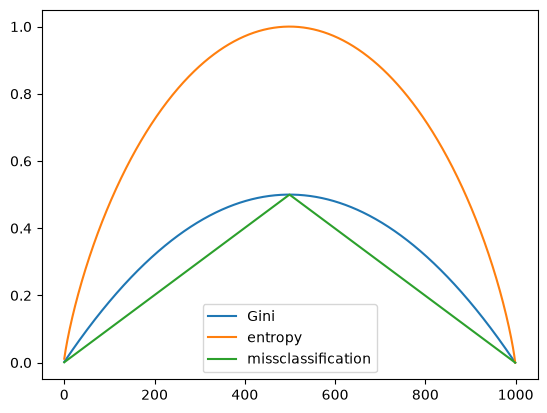

In [8]:
gs = []
es = []
ms = []
y = np.zeros(1000)
for i in range(1000):
    y[i] = 1
    gs.append(gini(y))
    es.append(entropy(y))
    ms.append(misclassification(y))
plt.plot(gs, label='Gini')
plt.plot(es, label='entropy')
plt.plot(ms, label='missclassification')
plt.legend()

Gini and entropy have the same shape, but nobody splits on the misclassification rate. Looking at your
plot, which property do the first two have that the third one lacks, and why does it matter when we compare
a parent node with the average of its two children?

*Answer:*

### Finding the best split

A split sends the rows with $x_j \leq t$ to the left child and the rest to the right child. Its quality is
the **weighted** impurity of the two children,

$$ I_{\text{split}} = \frac{n_L}{n} G(y_L) + \frac{n_R}{n} G(y_R) $$

and its **gain** is $G(y) - I_{\text{split}}$, i.e. the amount of impurity the question removed.

Write `split_impurity(y_left, y_right, criterion=gini)` and `gain(y, y_left, y_right, criterion=gini)`, and
check them on the two extreme cases.

```python
# the perfect split: each child is pure
split_impurity(np.array([0, 0]), np.array([1, 1]))    # -> 0.0
gain(np.array([0, 0, 1, 1]), np.array([0, 0]), np.array([1, 1]))           # -> 0.5

# the useless split: both children look exactly like the parent
split_impurity(np.array([0, 1]), np.array([0, 1]))    # -> 0.5
gain(np.array([0, 0, 1, 1]), np.array([0, 1]), np.array([0, 1]))           # -> 0.0
```

In [9]:
def split_impurity(y_left, y_right, criterion=gini):
    nl = len(y_left)
    nr = len(y_right)
    n = nl+nr
    return criterion(y_left)*(nl/n) + criterion(y_right)*(nr/n)

split_impurity(np.array([0, 0]), np.array([1, 1])),\
split_impurity(np.array([0, 1]), np.array([0, 1]))    # -> 0.0, 0.5

(np.float64(0.0), np.float64(0.5))

In [10]:
def gain(y, y_left, y_right, criterion=gini):
    return criterion(y) - split_impurity(y_left, y_right, criterion) 

gain(np.array([0, 0, 1, 1]), np.array([0, 0]), np.array([1, 1])),\
gain(np.array([0, 0, 1, 1]), np.array([0, 1]), np.array([0, 1]))           # -> 0.5, 0.0

(np.float64(0.5), np.float64(0.0))

Write `best_split(X, y, criterion=gini)`, which tries **every** column and **every** useful threshold, and
returns the best `(feature, threshold, gain)`, or `(None, None, 0.0)` when no split has a positive gain.

For a given column, the useful thresholds are the midpoints between consecutive values of the sorted unique
values of that column: any two thresholds between the same pair of observed values give the same partition,
so there is nothing to gain from trying more. Never keep a split that leaves a child empty.

*Loops are fine here (the algorithm really is a scan over columns and thresholds), but split `y` with a
boolean mask rather than with a third loop. How many splits does this evaluate, as a function of $n$ and of
the number of columns $p$ ?*

Check it on two hand-made tables, and verify the answer yourself:

```python
# only x1 carries the signal, and x2 is constant, so it offers no threshold at all
X1 = np.array([[0., 0.], [1., 0.], [2., 0.], [3., 0.]])
y1 = np.array([0, 0, 1, 1])
best_split(X1, y1)      # -> (0, 1.5, 0.5), the perfect split, halfway between x1 = 1 and x1 = 2

# now the signal is in x2, and x1 is a decoy that can only ever split the classes in half
X2 = np.array([[0., 5.], [1., 1.], [2., 5.], [3., 1.]])
y2 = np.array([1, 0, 1, 0])
best_split(X2, y2)      # -> (1, 3.0, 0.5), your loop must compare the columns, not stop at the first one
```

In [11]:
np.random.choice(10, 5)

array([0, 8, 1, 7, 8])

In [12]:
def best_split(X, y, criterion=gini, max_feature=None):
    if max_feature is None:
        max_feature = X.shape[1]
    best_feature = None
    best_threshold = None
    best_gain = 0.0
    for feature in np.random.choice(X.shape[1], max_feature, replace=False):
        sorted_values = np.sort(X[:,feature])
        for i in range(len(sorted_values)-1):
            a = sorted_values[i]
            b = sorted_values[i+1]
            threshold = (a+b)/2
            left = X[:,feature] < threshold
            right = ~left
            y_left = y[left]
            y_right = y[right]
            g = gain(y, y_left, y_right, criterion)
            if g > best_gain:
                best_gain = g
                best_feature = feature
                best_threshold = threshold
    return best_feature, best_threshold, best_gain

In [13]:
# only x1 carries the signal, and x2 is constant, so it offers no threshold at all
X1 = np.array([[0., 0.], [1., 0.], [2., 0.], [3., 0.]])
y1 = np.array([0, 0, 1, 1])
best_split(X1, y1)      # -> (0, 1.5, 0.5), the perfect split, halfway between x1 = 1 and x1 = 2

(np.int64(0), np.float64(1.5), np.float64(0.5))

In [14]:
# now the signal is in x2, and x1 is a decoy that can only ever split the classes in half
X2 = np.array([[0., 5.], [1., 1.], [2., 5.], [3., 1.]])
y2 = np.array([1, 0, 1, 0])
best_split(X2, y2)      # -> (1, 3.0, 0.5), your loop must compare the columns, not stop at the first one

(np.int64(1), np.float64(3.0), np.float64(0.5))

Run `best_split` on the training set and print the chosen column, threshold and gain. Plot the training
data with that split drawn on top, as a vertical line if the split is on $x_1$ and a horizontal one if it is
on $x_2$ (`plt.axvline` and `plt.axhline`).

Is it the split you would have drawn by hand? Does either child look pure?

gain: 0.21114369501466274
feature: 1
threshold: 0.11944765564468517


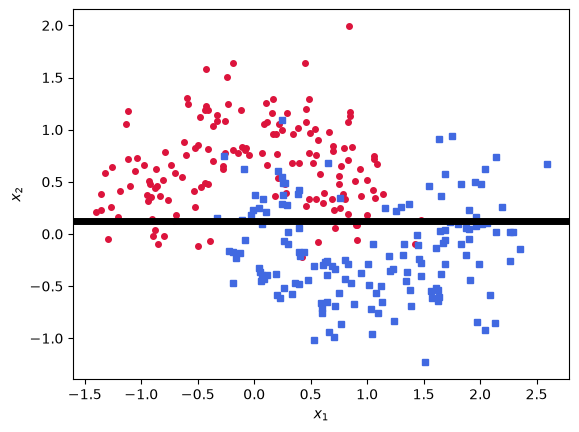

In [15]:
feature, threshold, g = best_split(X_train, y_train)
print("gain:", g)
print("feature:", feature)
print("threshold:", threshold)
plot_data(X_train, y_train)
plt.axhline(threshold, color='k', lw=5)

### Growing the tree

We now recurse. Represent a node as a dictionary, so the whole tree is one nested object:

```python
{'leaf': True,  'prediction': 0}
{'leaf': False, 'feature': 1, 'threshold': 0.337, 'left': {...}, 'right': {...}}
```

Write `build_tree(X, y, depth=0, max_depth=3, min_samples_leaf=1)`. The node becomes a **leaf** predicting
the majority class of its rows as soon as any of these holds:

- the node is pure,
- `depth == max_depth`,
- the node holds fewer than `2*min_samples_leaf` rows,
- `best_split` returns no split with a positive gain

Otherwise it stores the best question and calls itself on each child with `depth + 1`.

In [16]:
# {'leaf': False, 'feature': 0, 'threshold': 1.337, 'left': {'leaf': False, 'feature': 1, 'threshold': 0.337, 'left': {'leaf': True,  'prediction': 0}, 'right': {'leaf': True,  'prediction': 1}}, 'right': {'leaf': False, 'feature': 1, 'threshold': 0.337, 'left': {'leaf': True,  'prediction': 0}, 'right': {'leaf': True,  'prediction': 1}}}
def build_tree(X, y, depth=0, max_depth=3, min_sample_leaf=1, max_feature=None):
    if gini(y) == 0:
        return {'leaf': True, 'prediction': int(y[0])}
    if depth == max_depth:
        return {'leaf': True, 'prediction': int(np.mean(y+0.5))}
    if len(y) < 2* min_sample_leaf:
        return {'leaf': True, 'prediction': int(np.mean(y+0.5))}
    feature, threshold, g = best_split(X, y, max_feature=max_feature)
    if g <= 0:
        return {'leaf': True, 'prediction': int(np.mean(y+0.5))}
    left = X[:,feature] < threshold
    right = ~left
    y_left = y[left]
    y_right = y[right]
    X_left = X[left]
    X_right = X[right]
    return {
        'leaf': False, 
        'feature': feature,
        'threshold': threshold,
        'gain': g,
        'n': len(y),
        'left': build_tree(X_left, y_left, depth+1, max_depth, min_sample_leaf, max_feature=max_feature),
        'right': build_tree(X_right, y_right, depth+1, max_depth, min_sample_leaf, max_feature=max_feature),
    }
build_tree(X_train, y_train, max_depth=2, min_sample_leaf=1)


{'leaf': False,
 'feature': np.int64(1),
 'threshold': np.float64(0.11944765564468517),
 'gain': np.float64(0.21114369501466274),
 'n': 300,
 'left': {'leaf': False,
  'feature': np.int64(0),
  'threshold': np.float64(-0.3059028076283713),
  'gain': np.float64(0.09416384286311431),
  'n': 124,
  'left': {'leaf': True, 'prediction': 1},
  'right': {'leaf': True, 'prediction': 0}},
 'right': {'leaf': False,
  'feature': np.int64(0),
  'threshold': np.float64(1.1488022321072044),
  'gain': np.float64(0.1255059663160112),
  'n': 176,
  'left': {'leaf': True, 'prediction': 1},
  'right': {'leaf': True, 'prediction': 0}}}

Write `predict(tree, X)`, which returns the predicted label of every row of `X`.

Write it **recursively on arrays**, not point by point: at an internal node, build the boolean mask
`X[:, feature] <= threshold`, send `X[mask]` down the left child and `X[~mask]` down the right one, and write
the two answers back into the right positions of the output. A leaf simply returns its prediction repeated.
This costs one numpy operation per node instead of one tree walk per point, and the region plots below would
be painfully slow otherwise.

In [17]:
def predict(tree, X):
    if tree['leaf']:
        return np.ones(len(X)) * tree['prediction']
    left = X[:,tree['feature']] < tree['threshold']
    right = ~left
    X_left = X[left]
    X_right = X[right]
    left_pred = predict(tree['left'], X_left)
    right_pred = predict(tree['right'], X_right)
    pred = np.zeros(len(X))
    pred[left] = left_pred
    pred[right] = right_pred
    return pred

tree = build_tree(X_train, y_train, max_depth=3, min_sample_leaf=1)
predict(tree, X_train)

array([1., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

Grow a tree of depth $3$ on the training set. Print the training and the test accuracy, then plot the decision regions with `plot_regions`.

In [18]:
tree = build_tree(X_train, y_train, max_depth=5, min_sample_leaf=1)
acc_train = np.sum(predict(tree, X_train) ==  y_train) / len(y_train)
acc_test = np.sum(predict(tree, X_test)==  y_test) / len(y_test)
print(f'Training set accuracy: {acc_train*100:.2f} %')
print(f'Testing set accuracy: {acc_test*100:.2f} %')

Training set accuracy: 97.00 %
Testing set accuracy: 89.50 %


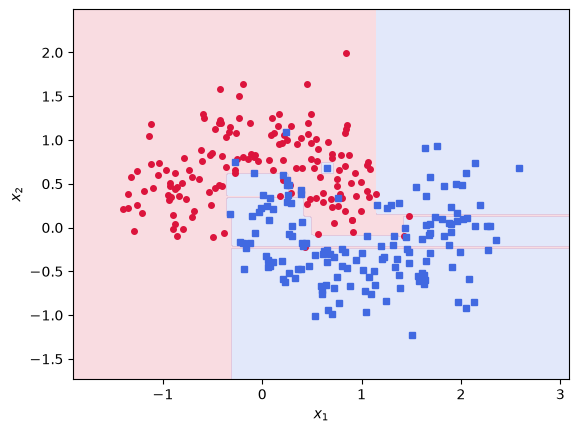

In [19]:
tree = build_tree(X_train, y_train, max_depth=8, min_sample_leaf=1)
plot_regions(lambda z: predict(tree, z), X_train, y_train)

### Depth is the capacity knob

Grow a tree for every `max_depth` from $0$ to $10$ and plot the training and the test accuracy against the
depth, on the same figure.

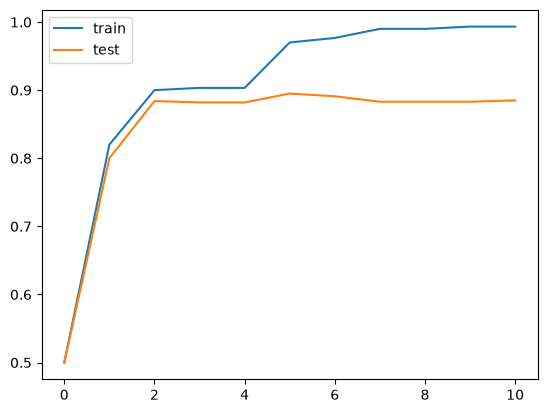

In [20]:
acc_train = []
acc_test = []
for m in range(11):
    tree = build_tree(X_train, y_train, max_depth=m, min_sample_leaf=1)
    acc_train.append( np.sum(predict(tree, X_train) ==  y_train) / len(y_train) )
    acc_test.append( np.sum(predict(tree, X_test)==  y_test) / len(y_test) )
plt.plot(acc_train, label='train')
plt.plot(acc_test, label='test')
plt.legend()
plt.show()

Plot the decision regions for `max_depth` $\in \{1, 3, 6, 12\}$, in four panels, with the test accuracy in
the title of each panel.

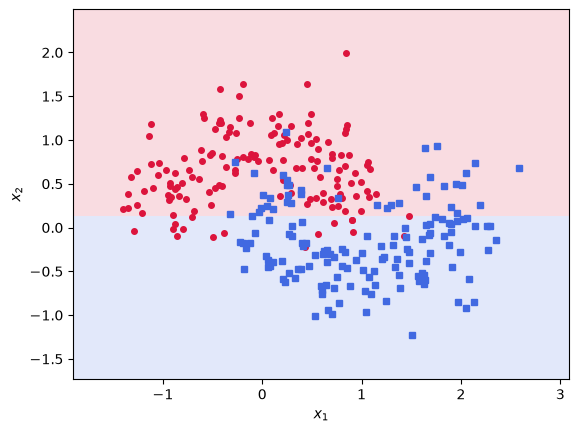

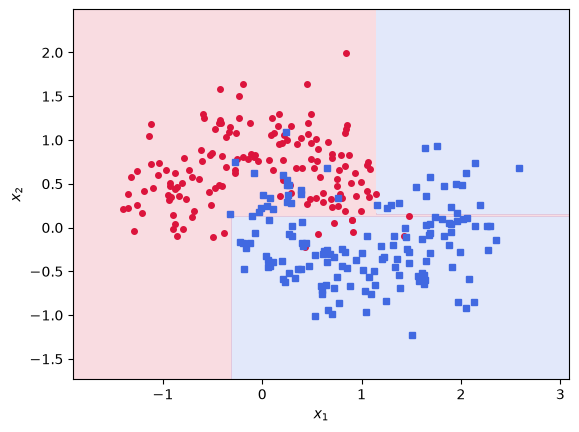

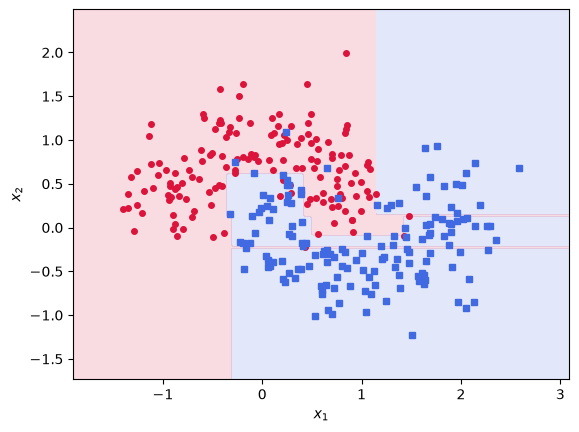

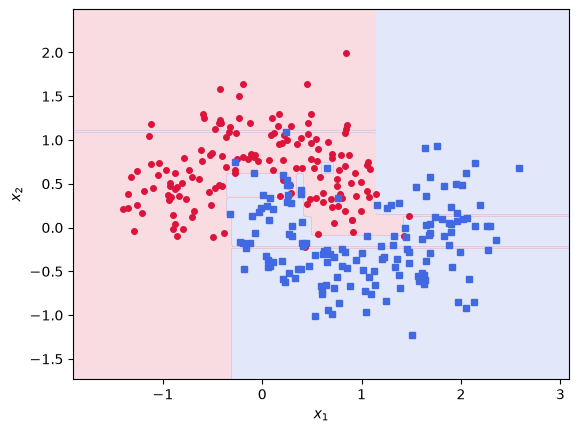

In [21]:
for m in [1, 3, 6, 12]:
    tree = build_tree(X_train, y_train, max_depth=m, min_sample_leaf=1)
    plot_regions(lambda z: predict(tree, z), X_train, y_train)
    plt.show()

`max_depth` is a blunt instrument: it stops every branch at the same level, whether or not that branch still
has something to learn. `min_samples_leaf` is the other classic knob, and it acts locally: a branch stops as
soon as its rows become too few to be trusted.

Grow a tree with `max_depth = 12` and `min_samples_leaf` $\in \{1, 5, 20\}$ and compare the training and test
accuracies. Which is the better way to control a tree here?

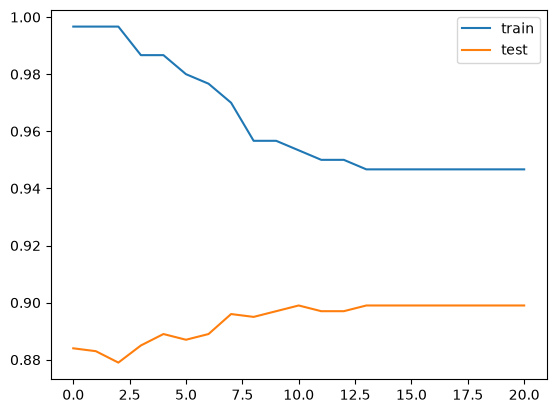

In [22]:
acc_train = []
acc_test = []
for m in range(21):
    tree = build_tree(X_train, y_train, max_depth=12, min_sample_leaf=m)
    acc_train.append( np.sum(predict(tree, X_train) ==  y_train) / len(y_train) )
    acc_test.append( np.sum(predict(tree, X_test)==  y_test) / len(y_test) )
plt.plot(acc_train, label='train')
plt.plot(acc_test, label='test')
plt.legend()
plt.show()

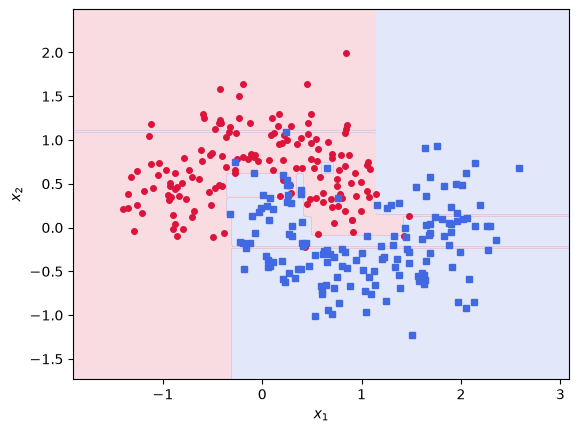

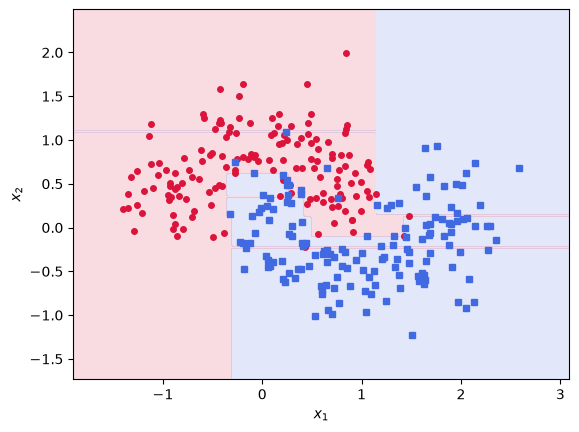

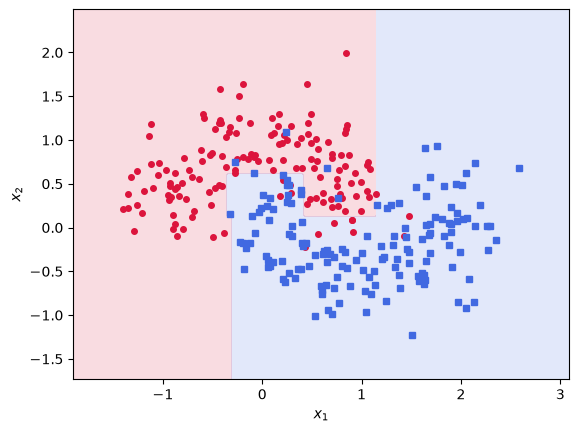

In [23]:
for m in [1, 5, 20]:
    tree = build_tree(X_train, y_train, max_depth=12, min_sample_leaf=m)
    plot_regions(lambda z: predict(tree, z), X_train, y_train)
    plt.show()

Check your implementation against `sklearn.tree.DecisionTreeClassifier(max_depth=3)` implemented below:
compare the training and test accuracies, and compare the root questions (1st feature / 1st threshold).

In [24]:
import sklearn

sktree = sklearn.tree.DecisionTreeClassifier(max_depth=3)
sktree.fit(X_train, y_train)
sktree.tree_.feature[0], sktree.tree_.threshold[0]

(np.int64(1), np.float64(0.11944765597581863))

In [25]:
tree = build_tree(X_train, y_train, max_depth=3, min_sample_leaf=1)
tree['feature'], tree['threshold']

(np.int64(1), np.float64(0.11944765564468517))

### The problem with a single tree

Draw three **bootstrap resamples** of the training set (draw $n$ row indices *with replacement*, with `np.random.choice`), grow a tree of depth $3$ on each, and plot the three sets of decision regions side by side.

The three trees see data from the very same distribution. Do they agree?

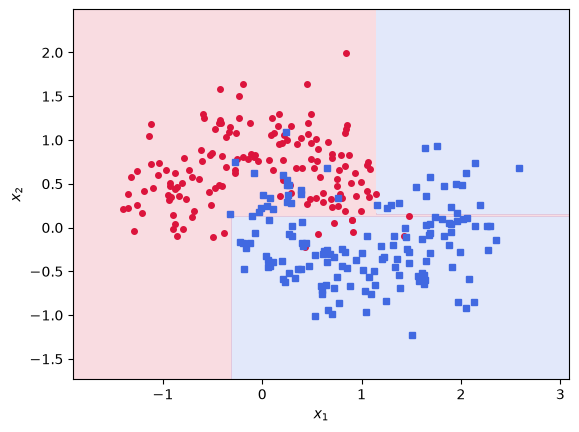

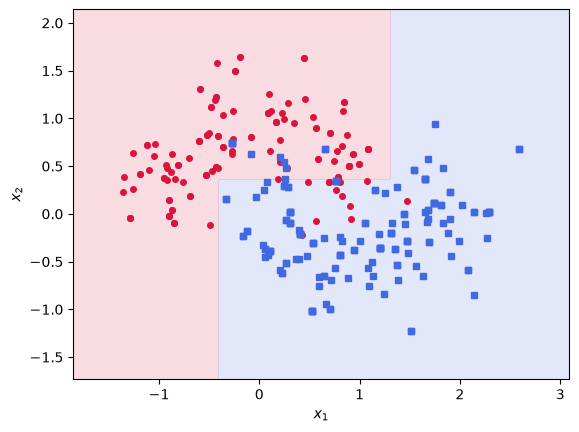

In [26]:
N = len(X_train)
indices = np.random.choice(N, N)
X_train2 = X_train[indices]
y_train2 = y_train[indices]

tree = build_tree(X_train, y_train, max_depth=3, min_sample_leaf=1)
tree2 = build_tree(X_train2, y_train2, max_depth=3, min_sample_leaf=1)


plot_regions(lambda z: predict(tree, z), X_train, y_train)
plt.show()
plot_regions(lambda z: predict(tree2, z), X_train2, y_train2)
plt.show()


-----

## Regression trees

**The same algorithm, with two words changed, predicts numbers instead of classes.**

Build a 1D regression problem: $N = 150$ points with $x_i$ uniform in $[-\pi, \pi]$ and
$y_i = \sin(x_i) + \varepsilon_i$, with $\varepsilon_i \approx \mathcal{N}(0, 0.2^2)$. Plot it.

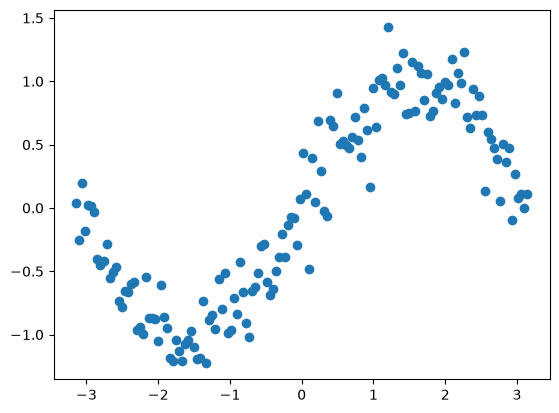

In [27]:
N = 150
xs = np.linspace(-np.pi, np.pi, N)
ys = np.sin(xs) + np.random.randn(N)*0.2
plt.scatter(xs, ys)

Only two things change when the target is a number:

- impurity becomes the **variance** of the node (`np.var`), since a node is pure when all its values are equal,
- a leaf predicts the **mean** of its rows instead of their majority class.

Write `build_tree_reg(X, y, depth=0, max_depth=3, min_samples_leaf=1)`.
Both `best_split` (with `criterion=np.var`) and `predict` should work unchanged, a leaf still just holds a `prediction`.

*Tip: `X` must stay 2D, so pass `x.reshape(-1, 1)`.*

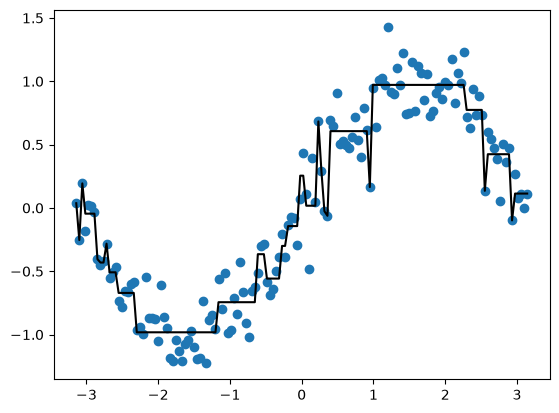

In [28]:
def build_tree_reg(X, y, depth=0, max_depth=3, min_sample_leaf=1):
    if np.var(y) == 0:
        return {'leaf': True, 'prediction': np.mean(y)}
    if depth == max_depth:
        return {'leaf': True, 'prediction': np.mean(y)}
    if len(y) < 2* min_sample_leaf:
        return {'leaf': True, 'prediction': np.mean(y)}
    feature, threshold, g = best_split(X, y, criterion=np.var)
    if g <= 0:
        return {'leaf': True, 'prediction': np.mean(y)}
    else:
        left = X[:,feature] < threshold
        right = ~left
        y_left = y[left]
        y_right = y[right]
        X_left = X[left]
        X_right = X[right]
        return {
            'leaf': False, 
            'feature': feature,
            'threshold': threshold,
            'gain': g,
            'n': len(y),
            'left': build_tree_reg(X_left, y_left, depth+1, max_depth, min_sample_leaf),
            'right': build_tree_reg(X_right, y_right, depth+1, max_depth, min_sample_leaf),
        }

tree_reg = build_tree_reg(xs.reshape(-1, 1), ys, max_depth=5, min_sample_leaf=1)
y_hat = predict(tree_reg, xs.reshape(-1, 1))
plt.scatter(xs, ys)
plt.plot(xs, y_hat, 'k')


Fit the regression tree for `max_depth` $\in \{1, 2, 3, ..., 10\}$ and plot, in four panels, the data together
with the prediction of the tree on a fine grid of $x$ values.

What shape does the fitted function have, and what is the prediction inside one leaf?

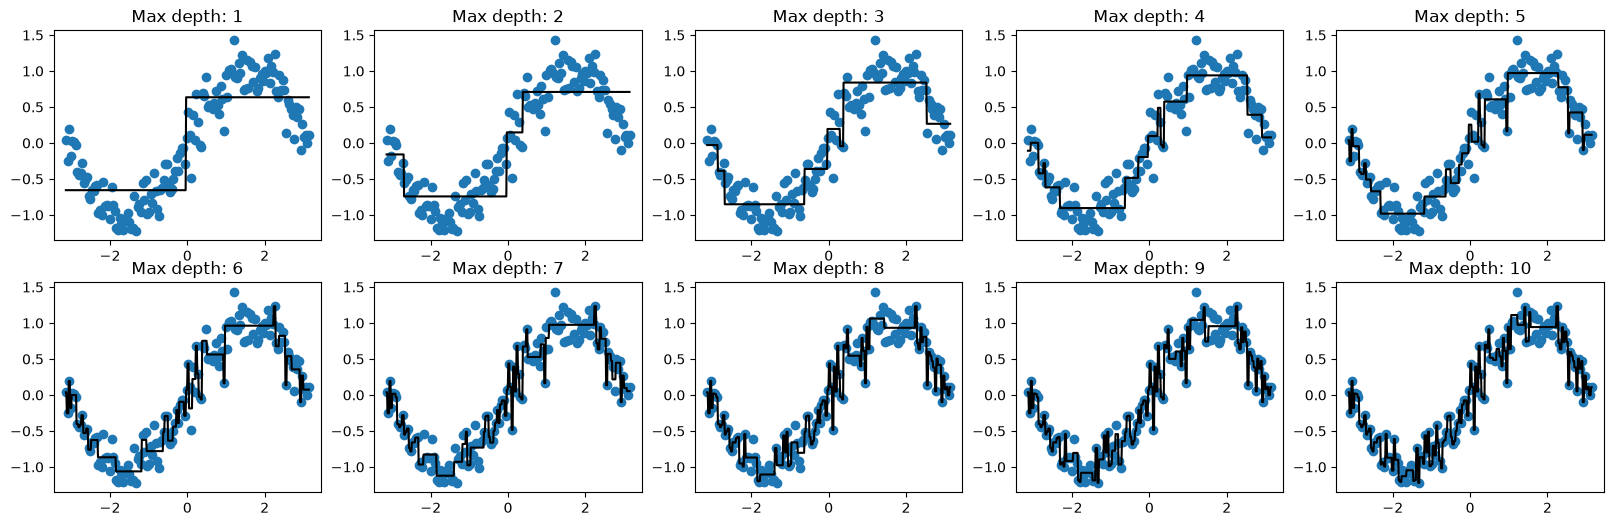

In [29]:
plt.figure(figsize=(20,6))
for m in range(10):
    plt.subplot(2,5,m+1)
    t = build_tree_reg(xs.reshape(-1, 1), ys, max_depth=m+1)
    X_lin = np.linspace(-np.pi, np.pi, 500).reshape(-1,1)
    y_pred = predict(t, X_lin)

    plt.scatter(xs, ys)
    plt.plot(X_lin, y_pred, 'k')
    plt.title(f'Max depth: {m+1}')
plt.show()

Take the depth-$3$ tree and predict on $x \in [-2\pi, 2\pi]$, i.e. well outside the range it was trained on. Plot
the prediction together with the true $\sin$ function.

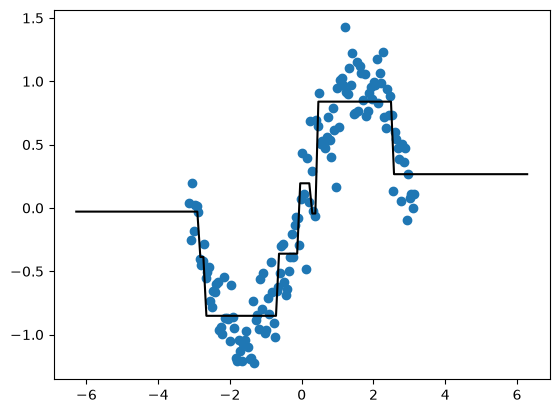

In [30]:
tree_reg = build_tree_reg(xs.reshape(-1, 1), ys, max_depth=3, min_sample_leaf=1)
xs_out = np.linspace(-2*np.pi, 2*np.pi, N)
y_hat = predict(tree_reg, xs_out.reshape(-1, 1))
plt.scatter(xs, ys)
plt.plot(xs_out, y_hat, 'k')

-----

## From one tree to a forest

**Bagging.** Write `fit_bag(X, y, n_trees, max_depth=8)`, which grows `n_trees` trees, each on its own bootstrap resample of the training set, and returns the list of trees.
Write `predict_bag(trees, X)`, which predicts by **majority vote** over the trees.

Plot the decision regions of the bag for `n_trees` $\in \{1, 10, 100\}$, with the test accuracy in each title.
Compare with the single depth-$8$ tree, and with the three unstable trees of the section above.

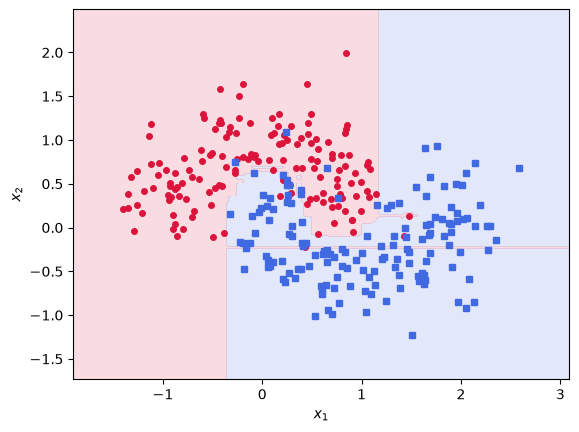

In [31]:
def fit_bag(X, y, n_trees, max_depth=8, max_feature=None):
    trees = []
    for _ in range(n_trees):
        N = len(X)
        indices = np.random.choice(N, N)
        X_resampled = X[indices]
        y_resampled = y[indices]
        tree = build_tree(X_resampled, y_resampled, max_depth=max_depth, max_feature=max_feature)
        trees.append(tree)
    return trees

def predict_bag(trees, X):
    ys = np.stack([predict(tree, X) for tree in trees])
    return ys.mean(axis=0).round()

trees = fit_bag(X_train, y_train, n_trees=10)
predict_bag(trees, X_train)

plot_regions(lambda z: predict_bag(trees, z), X_train, y_train)

**A forest needs its trees to disagree.**
Add a `max_features` argument to `best_split`: instead of trying all the columns, try only `max_features` of them, drawn at random **at every node** (`np.random.choice(p, max_features, replace=False)`).


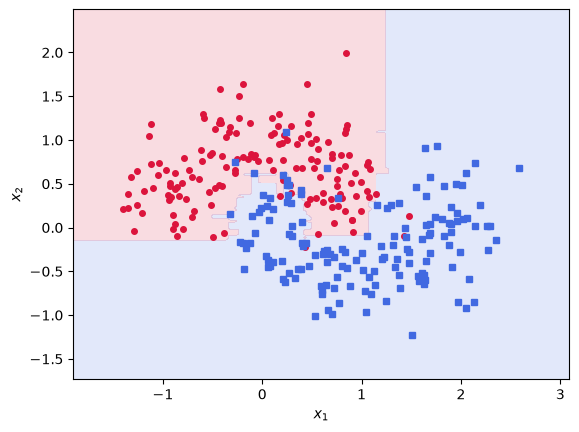

In [32]:
trees = fit_bag(X_train, y_train, n_trees=10, max_feature=1)
predict_bag(trees, X_train)
plot_regions(lambda z: predict_bag(trees, z), X_train, y_train)

Thread the `max_features` argument through `build_tree` and `fit_bag`.

This code generates data spreading the signal over many columns of unequal decaying strength:

In [41]:
def make_data(n):
    W = 0.7 ** np.arange(10)
    X = np.random.randn(n, 10)
    y = (X[:, :10] @ W + np.random.randn(n) * 0.5 > 0).astype(int)
    return X, y

X_train, y_train = make_data(200)
X_test,  y_test  = make_data(3000)

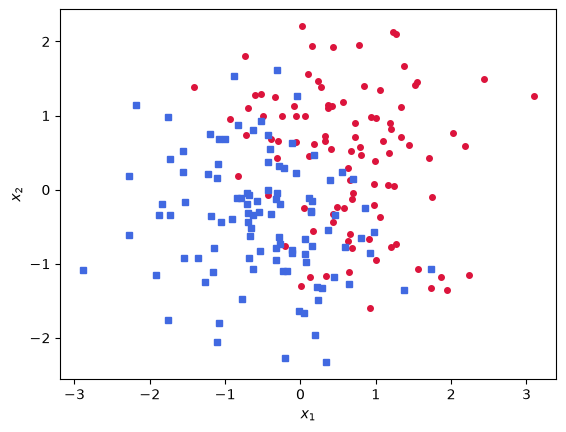

In [42]:
plot_data(X_train, y_train) # shows data in the first two columns, which are the ones carrying the most information

Fit a single tree of depth $6$ on it and record its test accuracy, as a baseline.

In [43]:
tree = build_tree(X_train, y_train, max_depth=6, min_sample_leaf=1)
acc_train = np.sum(predict(tree, X_train) ==  y_train) / len(y_train)
acc_test = np.sum(predict(tree, X_test)==  y_test) / len(y_test)
print(f'Training set accuracy: {acc_train*100:.2f} %')
print(f'Testing set accuracy: {acc_test*100:.2f} %')


Training set accuracy: 96.00 %
Testing set accuracy: 73.17 %


For every `max_features` from $1$ to $10$, grow a forest of $20-50$ trees of depth $6$ and record two numbers:

- the **test error** of the forest,
- the average **correlation** $\rho$ between the test predictions of two trees of that forest: stack the $20$
  prediction vectors into a $(20 \times n_{test})$ matrix, take `np.corrcoef` of it, and average the
  off-diagonal entries.

Plot the two values as curves in two panels.

.........

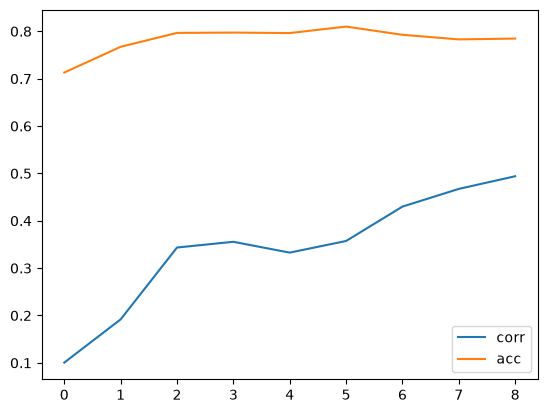

In [44]:
corrs = []
accs = []
for m in range(1, 10):
    n = 10
    trees = fit_bag(X_train, y_train, n_trees=n, max_depth=6, max_feature=m)
    votes = np.array([predict(tree, X_test) for tree in trees])
    y_pred = (votes.mean(axis=0) + 0.5).astype(int)
    acc = np.sum(y_pred == y_test) / len(y_pred)
    rhos = np.corrcoef(votes)
    corr = (np.sum(rhos) - np.trace(rhos)) / (2*n*(n-1)/2)
    corrs.append(corr)
    accs.append(acc)
    print('.', end='')

plt.plot(corrs, label='corr')
plt.plot(accs, label='acc')
plt.legend()

A tree can say how much each column contributed: sum, over every node that splits on column $j$, the gain of that split.

Write `feature_importance(tree, n_features)`, and plot the $10$ importances as a bar chart. Do the two informative columns stand out?

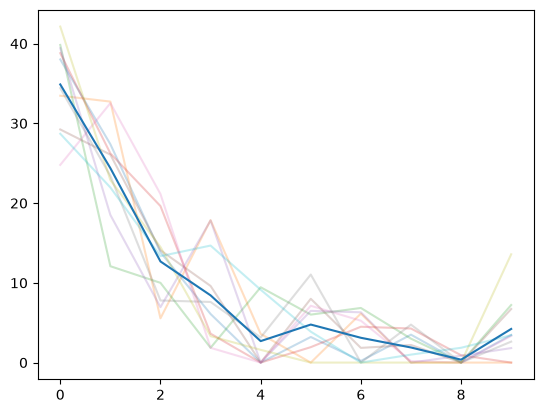

In [45]:
def feature_importance(tree, feature):
    if tree['leaf']:
        return 0
    else:
        gain = 0
        if tree['feature'] == feature:
            gain += tree['gain'] * tree['n']
        gain += feature_importance(tree['left'], feature)
        gain += feature_importance(tree['right'], feature)
        return gain

imp = np.zeros( (X_train.shape[1], len(trees)) )
for i,t in enumerate(trees):
    for j in range(X_train.shape[1]):
        imp[j,i] = feature_importance(t, j)
plt.plot(imp, alpha=0.25)
plt.plot(imp.mean(axis=1))
plt.show()